# Random Forest Analysis with just SSUSA Variables - Camera Level

In [83]:
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
OUTPUT_PATH = "../../outputs"

CAMERA_COMPARE_DATA = "camera_level_ssusa_iucn_comparison.pkl"

In [85]:
# Load camera-level comparison dataset
# ============================================================
camera_compare = pd.read_pickle(
    os.path.join(OUTPUT_PATH, CAMERA_COMPARE_DATA)
)

# preview
camera_compare.head()

,coord_id,Habitat,Development_Level,Feature_Type,Camera_Trap_Array,Longitude,Latitude,unique_nights,obs_species,S_obs,...,S_pred,overlap_species,missing_species,additional_species,union_species,overlap_n,missing_n,additional_n,union_n,jaccard_index
0,-100.23311_35.92725,grassland,wild,water source,{GeneHowe},-100.233110,35.927250,18.0,"{procyon lotor, odocoileus virginianus}",2,...,22,"{procyon lotor, odocoileus virginianus}","{xerospermophilus spilosoma, didelphis virgini...",{},"{xerospermophilus spilosoma, didelphis virgini...",2,20,0,22,0.090909
1,-100.24179_35.92768,grassland,wild,water source,{GeneHowe},-100.241790,35.927680,20.0,"{procyon lotor, odocoileus virginianus}",2,...,22,"{procyon lotor, odocoileus virginianus}","{xerospermophilus spilosoma, didelphis virgini...",{},"{xerospermophilus spilosoma, didelphis virgini...",2,20,0,22,0.090909
2,-100.241802_35.927679,grassland,wild,water source,{GeneHowe},-100.241802,35.927679,49.0,"{procyon lotor, odocoileus hemionus, odocoileu...",4,...,22,"{procyon lotor, odocoileus hemionus, odocoileu...","{lynx rufus, sylvilagus audubonii, ictidomys t...",{},"{xerospermophilus spilosoma, didelphis virgini...",4,18,0,22,0.181818
3,-100.24181_35.92775,grassland,wild,water source,{GeneHowe},-100.241810,35.927750,36.0,{odocoileus virginianus},1,...,22,{odocoileus virginianus},"{xerospermophilus spilosoma, didelphis virgini...",{},"{xerospermophilus spilosoma, didelphis virgini...",1,21,0,22,0.045455
4,-100.2421271_35.927561,grassland,wild,trail game,{GeneHowe},-100.242127,35.927561,4.0,{odocoileus virginianus},1,...,22,{odocoileus virginianus},"{xerospermophilus spilosoma, didelphis virgini...",{},"{xerospermophilus spilosoma, didelphis virgini...",1,21,0,22,0.045455


In [86]:
# print data types of all columns 
print(camera_compare.dtypes)

coord_id               object
Habitat                object
Development_Level      object
Feature_Type           object
Camera_Trap_Array      object
Longitude             float64
Latitude              float64
unique_nights         float64
obs_species            object
S_obs                   int64
pred_species           object
S_pred                  int64
overlap_species        object
missing_species        object
additional_species     object
union_species          object
overlap_n               int64
missing_n               int64
additional_n            int64
union_n                 int64
jaccard_index         float64
dtype: object


In [87]:
# Check latitude/longitude ranges
# ============================================================
camera_compare[["Latitude", "Longitude"]].describe()

,Latitude,Longitude
count,7303.000000,7303.000000
mean,38.652745,-90.255574
std,5.637139,15.370067
min,24.694860,-152.377920
25%,35.008340,-98.211870
50%,38.904560,-85.112230
75%,42.222661,-78.147125
max,59.452635,-68.611593


In [88]:
camera_compare["habitat_count"] = camera_compare["Habitat"].apply(
    lambda x: len(x) if isinstance(x, set) else (0 if pd.isna(x) else 1)
)

camera_compare["habitat_count"].value_counts()

habitat_count
1    7303
Name: count, dtype: int64

### Prepare Random Forest Dataset

In [89]:
# data copy for RF
# ------------------------------------------------------------
rf_ssusa = camera_compare.copy()

# Response variable
y = rf_ssusa["jaccard_index"].copy()

In [105]:
rf_ssusa[["Habitat", "Development_Level", "Feature_Type"]].notna().sum()

Habitat              7303
Development_Level    7303
Feature_Type         2163
dtype: int64

In [106]:
rf_ssusa["Feature_Type"].value_counts()

Feature_Type
trail game                               784
trail hiking                             377
other                                    352
road dirt                                316
water source                             284
road paved                                18
road dirt, trail hiking                    8
burrow                                     7
culvert                                    6
road bridge                                2
water source, trail hiking                 2
water source, road dirt                    2
fruiting tree                              2
carcass                                    1
road overpass                              1
water source, road dirt, trail hiking      1
Name: count, dtype: int64

In [ ]:
# HABITAT DUMMY VARIABLES (single label per camera)
# We already converted multi-label habitats to most common value
# so simple one-hot encoding is sufficient
# ============================================================
habitat_dummies = pd.get_dummies(
    rf_ssusa["Habitat"],
    prefix="habitat"
)

In [91]:
# DEVELOPMENT LEVEL DUMMY VARIABLES
# ============================================================

development_dummies = pd.get_dummies(
    rf_ssusa["Development_Level"],
    prefix="development"
)

In [92]:
# FEATURE TYPE DUMMY VARIABLES
# ============================================================

feature_dummies = pd.get_dummies(
    rf_ssusa["Feature_Type"],
    prefix="feature"
)

In [93]:
# Numeric predictor(s)
# ============================================================
X_num = rf_ssusa[["unique_nights"]].copy()

# ensure numeric
X_num["unique_nights"] = pd.to_numeric(
    X_num["unique_nights"],
    errors="coerce"
)



In [ ]:
# Combine all predictors
# ============================================================
X = pd.concat(
    [
        X_num,
        habitat_dummies,
        development_dummies,
        feature_dummies
    ],
    axis=1
)



In [95]:
# Check shapes
# ============================================================
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nColumns:")
print(X.columns.tolist())

X shape: (7303, 29)
y shape: (7303,)

Columns:
['unique_nights', 'habitat_anthropogenic', 'habitat_beach', 'habitat_chaparral', 'habitat_desert', 'habitat_forest', 'habitat_grassland', 'habitat_shrubland', 'habitat_wetland', 'development_rural', 'development_suburban', 'development_urban', 'development_wild', 'feature_burrow', 'feature_carcass', 'feature_culvert', 'feature_fruiting tree', 'feature_other', 'feature_road bridge', 'feature_road dirt', 'feature_road dirt, trail hiking', 'feature_road overpass', 'feature_road paved', 'feature_trail game', 'feature_trail hiking', 'feature_water source', 'feature_water source, road dirt', 'feature_water source, road dirt, trail hiking', 'feature_water source, trail hiking']


### Train/test split + RF model

In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [97]:
# Train Random Forest model
# ============================================================

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### Predictions + performance

In [98]:
# Model performance
# ============================================================
y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", round(r2, 3))
print("RMSE:", round(rmse, 3))

R²: 0.213
RMSE: 0.113


In [99]:
# Feature importance
# ============================================================
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(20)

unique_nights                      0.505376
development_wild                   0.110767
habitat_forest                     0.048151
feature_trail game                 0.047440
feature_trail hiking               0.034458
habitat_grassland                  0.034092
development_rural                  0.033366
development_suburban               0.028860
feature_water source               0.028490
habitat_wetland                    0.027227
feature_other                      0.025539
feature_road dirt                  0.021243
development_urban                  0.019201
habitat_anthropogenic              0.014195
habitat_desert                     0.009998
feature_road paved                 0.002927
habitat_shrubland                  0.002161
feature_road dirt, trail hiking    0.002098
habitat_chaparral                  0.001274
feature_burrow                     0.001052
dtype: float64

### Visualizations

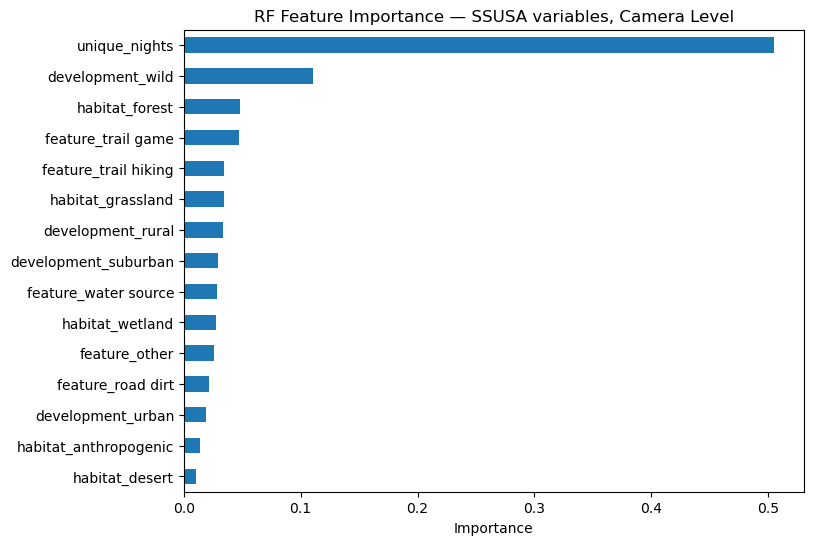

In [107]:
# Plot feature importance
# ============================================================
import matplotlib.pyplot as plt

top_imp = importance.head(15)

plt.figure(figsize=(8,6))

top_imp.sort_values().plot(
    kind="barh"
)

plt.xlabel("Importance")
plt.title("RF Feature Importance — SSUSA variables, Camera Level")

plt.show()

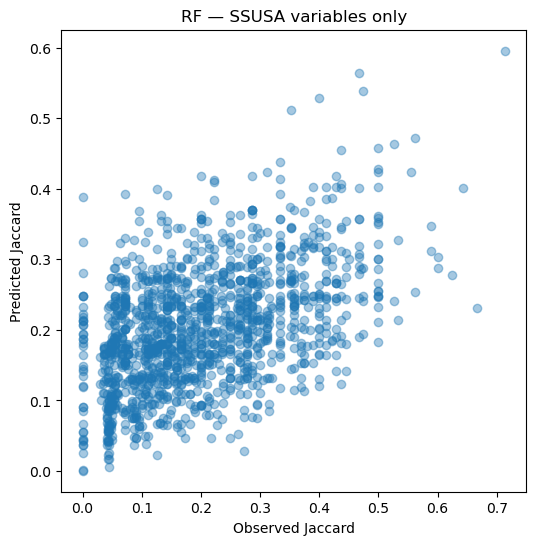

In [101]:
# Observed vs predicted
# ============================================================
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.4)

plt.xlabel("Observed Jaccard")
plt.ylabel("Predicted Jaccard")

plt.title("RF — SSUSA variables only")

plt.show()

<Figure size 600x400 with 0 Axes>

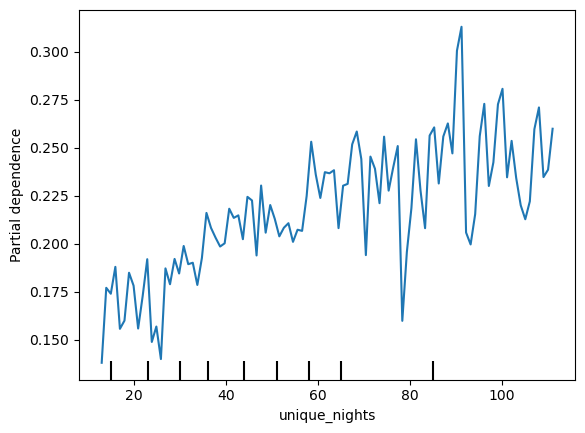

In [102]:
from sklearn.inspection import PartialDependenceDisplay

plt.figure(figsize=(6,4))

PartialDependenceDisplay.from_estimator(
    rf,
    X,
    ["unique_nights"]
)

plt.show()

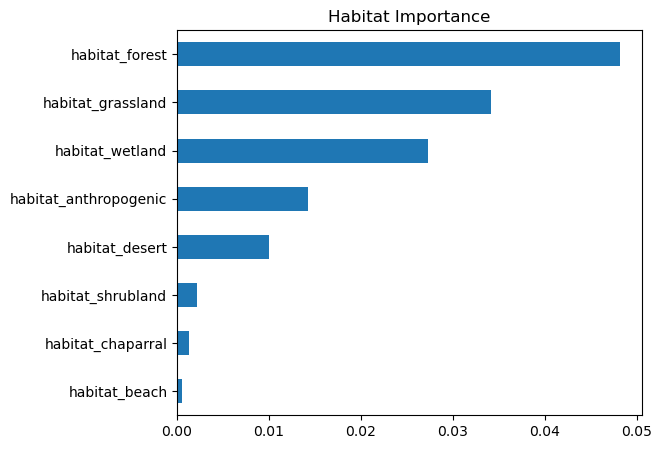

In [103]:
habitat_imp = importance[
    importance.index.str.startswith("habitat")
]

plt.figure(figsize=(6,5))

habitat_imp.sort_values().plot(kind="barh")

plt.title("Habitat Importance")
plt.show()

<Axes: xlabel='group'>

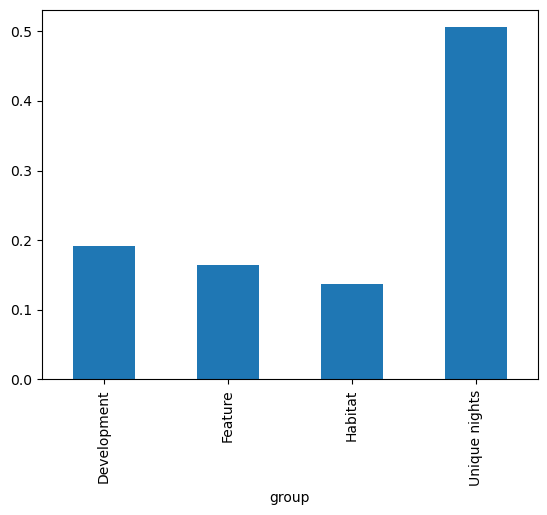

In [104]:
def group(col):
    if col.startswith("habitat"):
        return "Habitat"
    elif col.startswith("development"):
        return "Development"
    elif col.startswith("feature"):
        return "Feature"
    else:
        return "Unique nights"

group_imp = (
    importance
    .rename_axis("feature")
    .reset_index(name="importance")
)

group_imp["group"] = group_imp["feature"].apply(group)

group_imp = (
    group_imp.groupby("group")["importance"]
    .sum()
)

group_imp.plot(kind="bar")
